# Taller Práctico: Modulaciones Digitales y Canal
## ASK, PSK, FSK, QAM y APSK
**Teoría de Señales — Universidad Nacional de Colombia**

---

### Objetivo
Implementar un sistema completo de comunicaciones digitales:

$$\text{Bits} \rightarrow \text{Modulación} \rightarrow \text{Canal} \rightarrow \text{Demodulación}$$

y analizar:
- Precisión de detección (BER)
- Efecto del ruido (AWGN)
- Efecto del shaping (Raised Cosine)
- Ocupación espectral (PSD)

---

### Concepto Clave
Toda modulación puede representarse como:

$$s(t) = I_k \cos(2\pi f_c t) - Q_k \sin(2\pi f_c t)$$

donde $I_k$ y $Q_k$ son las componentes en fase y cuadratura del símbolo $k$.

## Imports y Configuración General

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.signal import welch

# Reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# Parámetros globales
N         = 500          # Número de bits
fc        = 10.0         # Frecuencia portadora (Hz)
fs        = 200.0        # Frecuencia de muestreo (Hz)
sps       = int(fs/fc)   # Muestras por símbolo
t_sym     = 1.0 / fc     # Duración de un símbolo
t         = np.arange(sps) / fs  # Vector de tiempo para un símbolo

print(f'Bits: {N} | fc={fc} Hz | fs={fs} Hz | Muestras/símbolo: {sps}')

Bits: 500 | fc=10.0 Hz | fs=200.0 Hz | Muestras/símbolo: 20


---
## Parte 1 – Generación de Bits

Generamos una secuencia aleatoria de $N$ bits equiprobables $\{0, 1\}$ usando PyTorch.

Primeros 20 bits: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
Proporción de 1s: 0.512  (esperado ≈ 0.5)


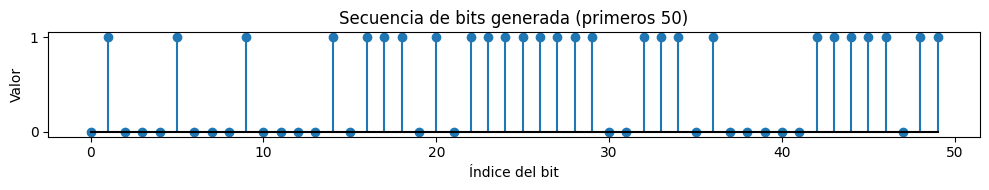

In [15]:
# Generación de bits con PyTorch
bits = torch.randint(0, 2, (N,))  # Tensor de bits {0, 1}

print(f'Primeros 20 bits: {bits[:20].numpy()}')
print(f'Proporción de 1s: {bits.float().mean().item():.3f}  (esperado ≈ 0.5)')

# Visualizar distribución
fig, ax = plt.subplots(figsize=(10, 2))
ax.stem(bits[:50].numpy(), markerfmt='C0o', linefmt='C0-', basefmt='k-')
ax.set_xlabel('Índice del bit')
ax.set_ylabel('Valor')
ax.set_title('Secuencia de bits generada (primeros 50)')
ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

---
## Parte 2 – Modulación ASK y BPSK

### ASK Unipolar (Amplitude Shift Keying)
- Bit 0 → Amplitud 0
- Bit 1 → Amplitud $A$

$$s_{ASK}(t) = A \cdot b_k \cdot \cos(2\pi f_c t)$$

### BPSK (Binary Phase Shift Keying)
- Bit 0 → Fase $\pi$ → símbolo $-1$
- Bit 1 → Fase $0$  → símbolo $+1$

$$s_{BPSK}(t) = (2b_k - 1) \cdot \cos(2\pi f_c t)$$

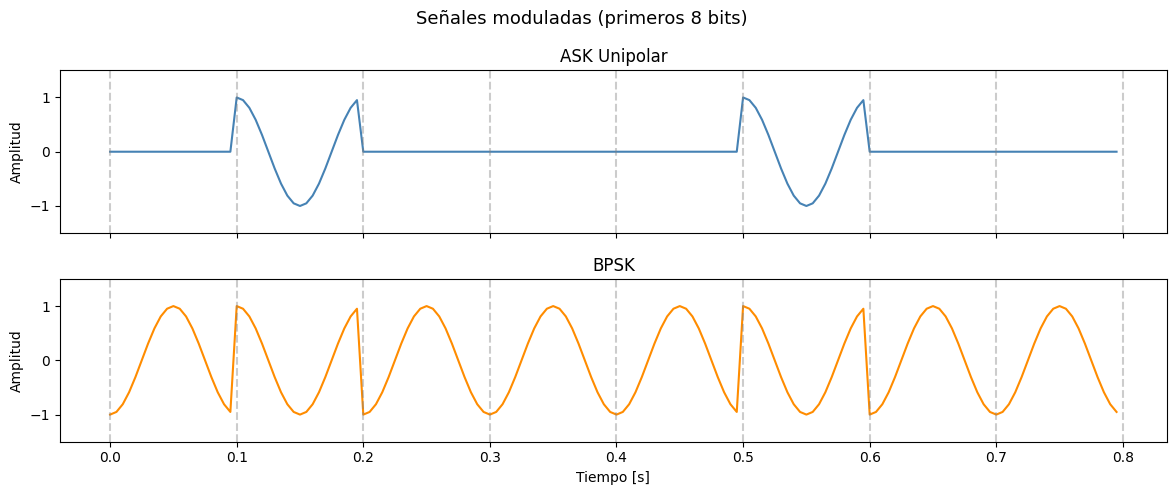

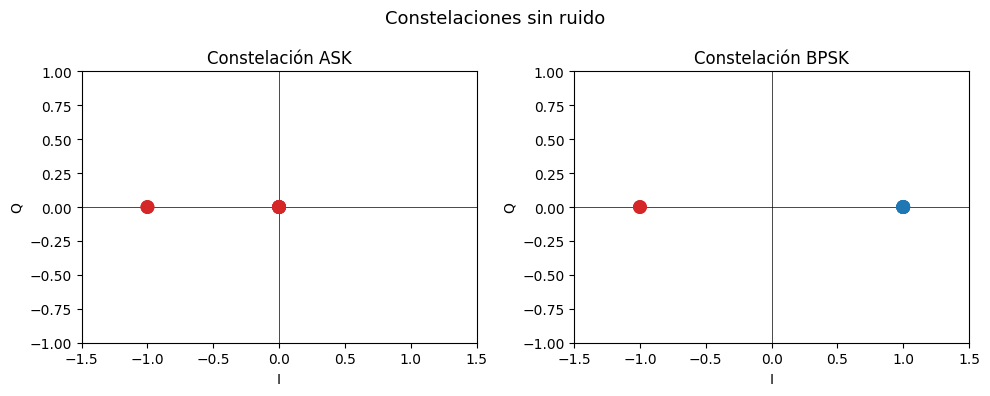

In [16]:
def modulate_ask(bits, t, fc, A=1.0):
    """ASK unipolar: bit=0 → 0, bit=1 → A·cos(2π·fc·t)"""
    signal = []
    for b in bits:
        signal.append(A * b.float() * torch.tensor(np.cos(2 * np.pi * fc * t), dtype=torch.float32))
    return torch.cat(signal)

def modulate_bpsk(bits, t, fc):
    """BPSK: bit=0 → -cos, bit=1 → +cos"""
    symbols = 2.0 * bits.float() - 1.0  # Mapeo: {0,1} → {-1,+1}
    signal = []
    for s in symbols:
        signal.append(s * torch.tensor(np.cos(2 * np.pi * fc * t), dtype=torch.float32))
    return torch.cat(signal)

# Modular (usamos los primeros 8 bits para visualización)
N_vis = 8
bits_vis = bits[:N_vis]

ask_sig  = modulate_ask(bits_vis, t, fc)
bpsk_sig = modulate_bpsk(bits_vis, t, fc)
t_total  = np.arange(len(ask_sig)) / fs

# ---- Señales en el tiempo ----
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_total, ask_sig.numpy(), color='steelblue')
axes[0].set_title('ASK Unipolar')
axes[0].set_ylabel('Amplitud')
axes[0].set_ylim(-1.5, 1.5)

axes[1].plot(t_total, bpsk_sig.numpy(), color='darkorange')
axes[1].set_title('BPSK')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylim(-1.5, 1.5)

# Marcar límites de símbolo
for ax in axes:
    for k in range(N_vis + 1):
        ax.axvline(k * t_sym, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Señales moduladas (primeros 8 bits)', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Constelaciones ----
# Tomamos la muestra central de cada símbolo (correlación con portadora)
def get_constellation(signal, sps):
    n_sym = len(signal) // sps
    mid   = sps // 2
    return signal[mid::sps][:n_sym].numpy()

ask_pts  = get_constellation(ask_sig, sps)
bpsk_pts = get_constellation(bpsk_sig, sps)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(ask_pts, np.zeros_like(ask_pts), c=['C0' if p > 0 else 'C3' for p in ask_pts], s=80, zorder=3)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('Constelación ASK'); axes[0].set_xlabel('I'); axes[0].set_ylabel('Q')
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1, 1)

axes[1].scatter(bpsk_pts, np.zeros_like(bpsk_pts), c=['C0' if p > 0 else 'C3' for p in bpsk_pts], s=80, zorder=3)
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
axes[1].set_title('Constelación BPSK'); axes[1].set_xlabel('I'); axes[1].set_ylabel('Q')
axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1, 1)

plt.suptitle('Constelaciones sin ruido', fontsize=13)
plt.tight_layout()
plt.show()

### ❓ Pregunta — Equivalencia BPSK y ASK Bipolar

**Demostración experimental:** Si aplicamos a la ASK unipolar la transformación $s_{bipolar}(t) = 2 \cdot s_{ASK}(t) - \cos(2\pi f_c t)$, obtenemos exactamente la señal BPSK. Verifícalo comparando punto a punto ambas señales en la siguiente celda.

Error máximo entre ASK bipolar y BPSK: 0.00e+00  →  ✅ Son equivalentes


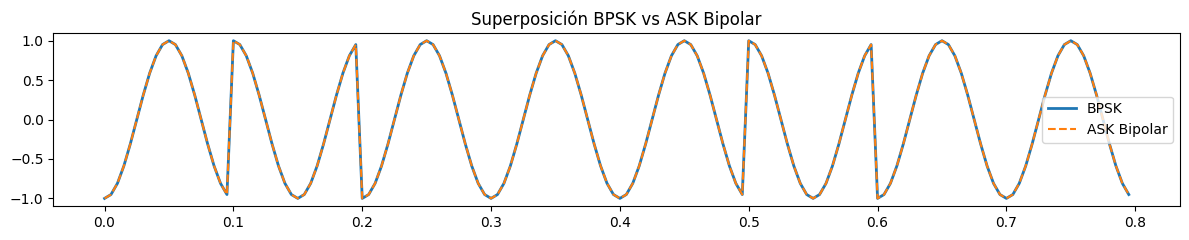

In [17]:
# ASK bipolar = 2·ASK_unipolar - portadora
carrier   = torch.tensor(np.tile(np.cos(2 * np.pi * fc * t), N_vis), dtype=torch.float32)
ask_bipolar = 2.0 * ask_sig - carrier

error = (ask_bipolar - bpsk_sig).abs().max().item()
print(f'Error máximo entre ASK bipolar y BPSK: {error:.2e}  →  {"✅ Son equivalentes" if error < 1e-5 else "❌ Diferencias encontradas"}')

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(t_total, bpsk_sig.numpy(), label='BPSK', lw=2)
ax.plot(t_total, ask_bipolar.numpy(), label='ASK Bipolar', lw=1.5, linestyle='--')
ax.set_title('Superposición BPSK vs ASK Bipolar')
ax.legend(); plt.tight_layout(); plt.show()

---
## Parte 3 – Canal con Ruido AWGN

El modelo de canal es:
$$r(t) = s(t) + n(t), \quad n(t) \sim \mathcal{N}(0, \sigma^2)$$

La relación señal-ruido se define como:
$$\text{SNR}_{dB} = 10 \log_{10}\left(\frac{P_s}{\sigma^2}\right)$$

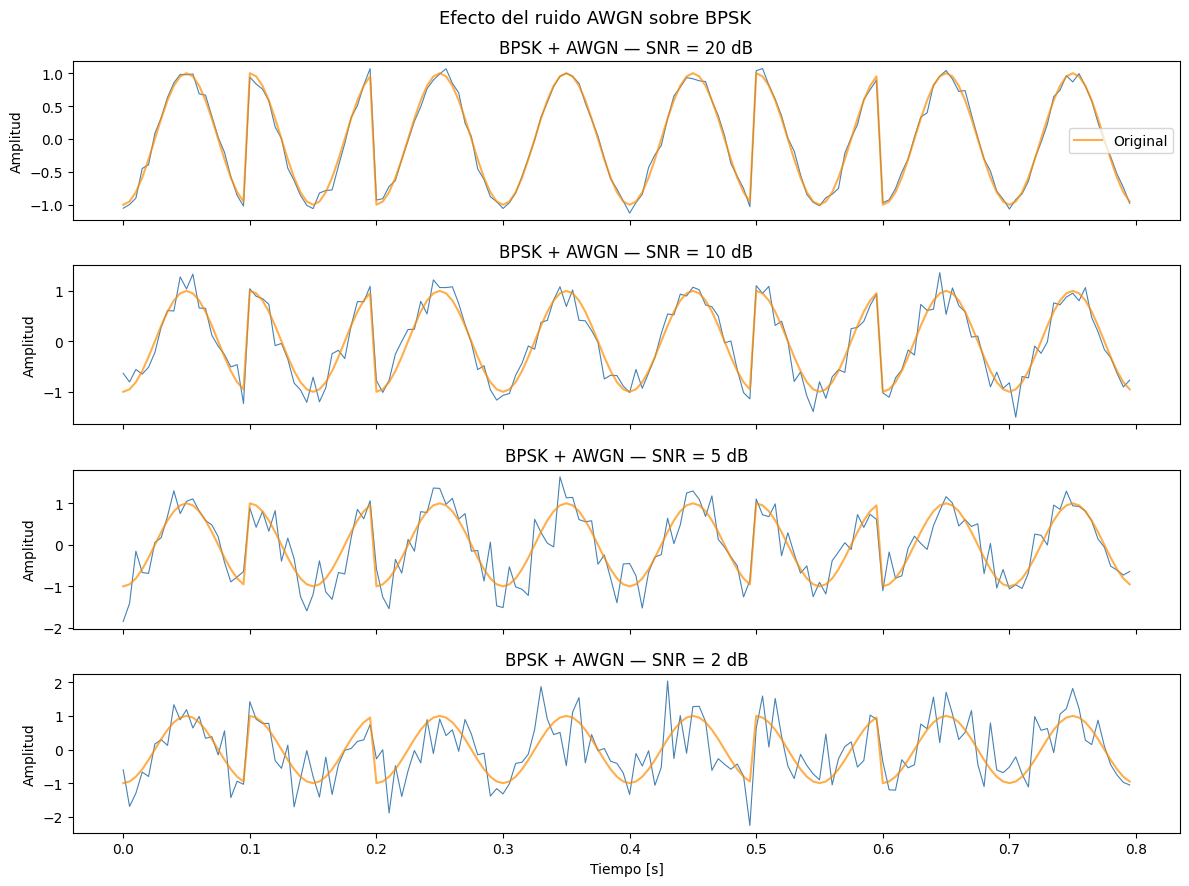

In [18]:
def add_awgn(signal: torch.Tensor, snr_db: float) -> torch.Tensor:
    """Agrega ruido AWGN a la señal para un SNR dado en dB."""
    signal_power = signal.pow(2).mean()
    snr_linear   = 10 ** (snr_db / 10)
    sigma        = torch.sqrt(signal_power / snr_linear)
    noise        = torch.randn_like(signal) * sigma
    return signal + noise, noise

# Modular toda la secuencia de bits
bpsk_full = modulate_bpsk(bits, t, fc)

snr_levels = [20, 10, 5, 2]
fig, axes = plt.subplots(len(snr_levels), 1, figsize=(12, 9), sharex=True)

for ax, snr in zip(axes, snr_levels):
    r, _ = add_awgn(bpsk_full, snr)
    t_plot = np.arange(len(r)) / fs
    ax.plot(t_plot[:8*sps], r[:8*sps].numpy(), color='steelblue', lw=0.8)
    ax.plot(t_plot[:8*sps], bpsk_full[:8*sps].numpy(), color='darkorange', lw=1.5, alpha=0.7, label='Original')
    ax.set_ylabel('Amplitud')
    ax.set_title(f'BPSK + AWGN — SNR = {snr} dB')

axes[-1].set_xlabel('Tiempo [s]')
axes[0].legend()
plt.suptitle('Efecto del ruido AWGN sobre BPSK', fontsize=13)
plt.tight_layout()
plt.show()

---
## Parte 4 – Demodulación y Reconstrucción

### Detectores
- **ASK:** comparación con umbral $\tau = A/2$
- **BPSK:** decisión por signo de la correlación con la portadora

$$\hat{b}_k = \begin{cases} 1 & \text{si } \int_{kT}^{(k+1)T} r(t)\cos(2\pi f_c t)\,dt \geq 0 \\ 0 & \text{en otro caso} \end{cases}$$

### Métrica BER
$$\text{BER} = \frac{\text{bits errados}}{\text{bits totales}}$$

In [19]:
def correlate_demod(received: torch.Tensor, t_sym_arr, fc, sps, mode='bpsk'):
    """Demodulador por correlación con la portadora."""
    carrier_sym = torch.tensor(np.cos(2 * np.pi * fc * t_sym_arr), dtype=torch.float32)
    n_sym       = len(received) // sps
    decisions   = []
    for k in range(n_sym):
        chunk    = received[k * sps:(k + 1) * sps]
        corr_val = (chunk * carrier_sym).sum()
        if mode == 'bpsk':
            decisions.append(1 if corr_val >= 0 else 0)
        else:  # ASK: umbral en A/4 (mitad de correlación máxima)
            decisions.append(1 if corr_val >= sps / 4 else 0)
    return torch.tensor(decisions)

def ber(bits_tx: torch.Tensor, bits_rx: torch.Tensor) -> float:
    return (bits_tx != bits_rx).float().mean().item()

# Modulaciones completas
ask_full  = modulate_ask(bits, t, fc)
bpsk_full = modulate_bpsk(bits, t, fc)

snr_test = 20  # dB
ask_rx,  _ = add_awgn(ask_full,  snr_test)
bpsk_rx, _ = add_awgn(bpsk_full, snr_test)

bits_ask_hat  = correlate_demod(ask_rx,  t, fc, sps, mode='ask')
bits_bpsk_hat = correlate_demod(bpsk_rx, t, fc, sps, mode='bpsk')

ber_ask  = ber(bits, bits_ask_hat)
ber_bpsk = ber(bits, bits_bpsk_hat)

print(f'SNR = {snr_test} dB')
print(f'  BER ASK  = {ber_ask:.4f}  ({int(ber_ask*N)} errores de {N})')
print(f'  BER BPSK = {ber_bpsk:.4f}  ({int(ber_bpsk*N)} errores de {N})')

SNR = 20 dB
  BER ASK  = 0.0000  (0 errores de 500)
  BER BPSK = 0.0000  (0 errores de 500)


### ❓ Pregunta — ¿Qué modulación presenta menor BER?

**Respuesta esperada:** BPSK presenta menor BER que ASK unipolar para el mismo SNR, porque en BPSK los dos puntos de la constelación están separados por una distancia euclidiana de **2** (de $-1$ a $+1$), mientras que en ASK unipolar la distancia es solo **1** (de $0$ a $1$). Mayor distancia entre símbolos implica mayor robustez al ruido.

---
## Parte 5 – Modulación FSK

### BFSK (Binary Frequency Shift Keying)
- Bit 0 → frecuencia $f_0$
- Bit 1 → frecuencia $f_1$

$$s_{FSK}(t) = \cos\left(2\pi f_{b_k} t\right)$$

La demodulación se realiza por correlación (banco de filtros): se correlaciona la señal recibida con ambas portadoras y se decide según cuál produce mayor energía.

BER FSK  = 0.0000  (SNR=20 dB)
BER BPSK = 0.0000  (SNR=20 dB)


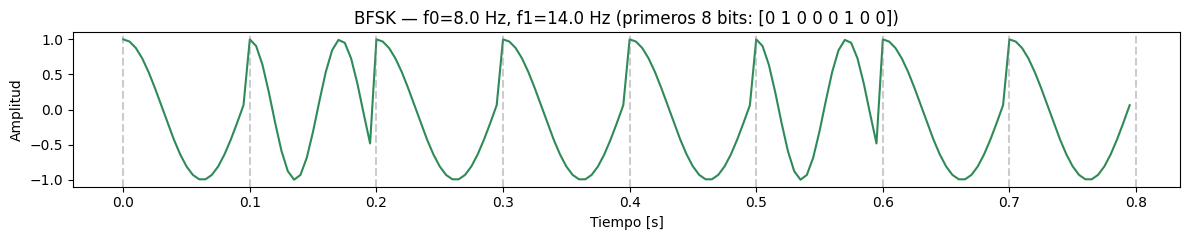

In [20]:
f0, f1 = 8.0, 14.0  # Hz — frecuencias FSK

def modulate_fsk(bits, t, f0, f1):
    """BFSK: bit=0 → f0, bit=1 → f1"""
    signal = []
    for b in bits:
        f = f1 if b.item() == 1 else f0
        signal.append(torch.tensor(np.cos(2 * np.pi * f * t), dtype=torch.float32))
    return torch.cat(signal)

def demod_fsk(received, t, f0, f1, sps):
    """Demodulación FSK por correlación (banco de dos filtros)."""
    c0 = torch.tensor(np.cos(2 * np.pi * f0 * t), dtype=torch.float32)
    c1 = torch.tensor(np.cos(2 * np.pi * f1 * t), dtype=torch.float32)
    n_sym = len(received) // sps
    decisions = []
    for k in range(n_sym):
        chunk = received[k * sps:(k + 1) * sps]
        e0 = (chunk * c0).sum().abs()
        e1 = (chunk * c1).sum().abs()
        decisions.append(1 if e1 >= e0 else 0)
    return torch.tensor(decisions)

fsk_full = modulate_fsk(bits, t, f0, f1)
fsk_rx, _ = add_awgn(fsk_full, snr_test)
bits_fsk_hat = demod_fsk(fsk_rx, t, f0, f1, sps)
ber_fsk = ber(bits, bits_fsk_hat)

print(f'BER FSK  = {ber_fsk:.4f}  (SNR={snr_test} dB)')
print(f'BER BPSK = {ber_bpsk:.4f}  (SNR={snr_test} dB)')

# Visualización señal FSK
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(np.arange(8*sps)/fs, fsk_full[:8*sps].numpy(), color='seagreen')
for k in range(9):
    ax.axvline(k * t_sym, color='gray', linestyle='--', alpha=0.4)
ax.set_title(f'BFSK — f0={f0} Hz, f1={f1} Hz (primeros 8 bits: {bits[:8].numpy()})')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Amplitud')
plt.tight_layout(); plt.show()

---
## Parte 6 – Análisis Espectral (PSD)

Usamos el método de **Welch** para estimar la Densidad Espectral de Potencia (PSD) de cada modulación.

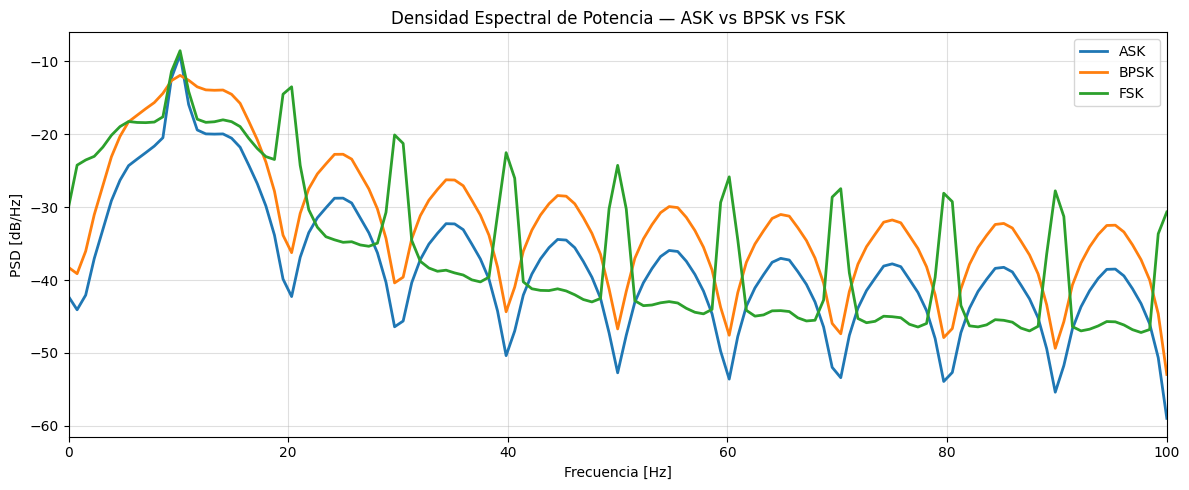

In [21]:
def compute_psd(signal: torch.Tensor, fs: float):
    """Calcula PSD con método de Welch."""
    f, Pxx = welch(signal.numpy(), fs=fs, nperseg=256)
    return f, 10 * np.log10(Pxx + 1e-12)  # en dB

f_ask,  P_ask  = compute_psd(ask_full,  fs)
f_bpsk, P_bpsk = compute_psd(bpsk_full, fs)
f_fsk,  P_fsk  = compute_psd(fsk_full,  fs)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(f_ask,  P_ask,  label='ASK',  lw=2)
ax.plot(f_bpsk, P_bpsk, label='BPSK', lw=2)
ax.plot(f_fsk,  P_fsk,  label='FSK',  lw=2)
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('PSD [dB/Hz]')
ax.set_title('Densidad Espectral de Potencia — ASK vs BPSK vs FSK')
ax.legend()
ax.set_xlim(0, fs/2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### ❓ Pregunta — ¿Cuál modulación ocupa mayor ancho de banda?

**Respuesta esperada:** **FSK** ocupa mayor ancho de banda, porque utiliza dos frecuencias diferentes ($f_0$ y $f_1$), generando dos lóbulos espectrales centrados en cada una. ASK y BPSK concentran su energía alrededor de una sola portadora $f_c$, ocupando menos espectro para la misma tasa de datos.

---
## Parte 7 – Pulse Shaping con Raised Cosine

Las transiciones abruptas entre símbolos generan alto contenido de altas frecuencias (lóbulos laterales en el espectro). El filtro **Raised Cosine** suaviza estas transiciones:

$$h_{RC}(t) = \text{sinc}\left(\frac{t}{T}\right) \cdot \frac{\cos(\pi \beta t / T)}{1 - (2\beta t / T)^2}$$

donde $\beta \in [0,1]$ es el **roll-off factor**.

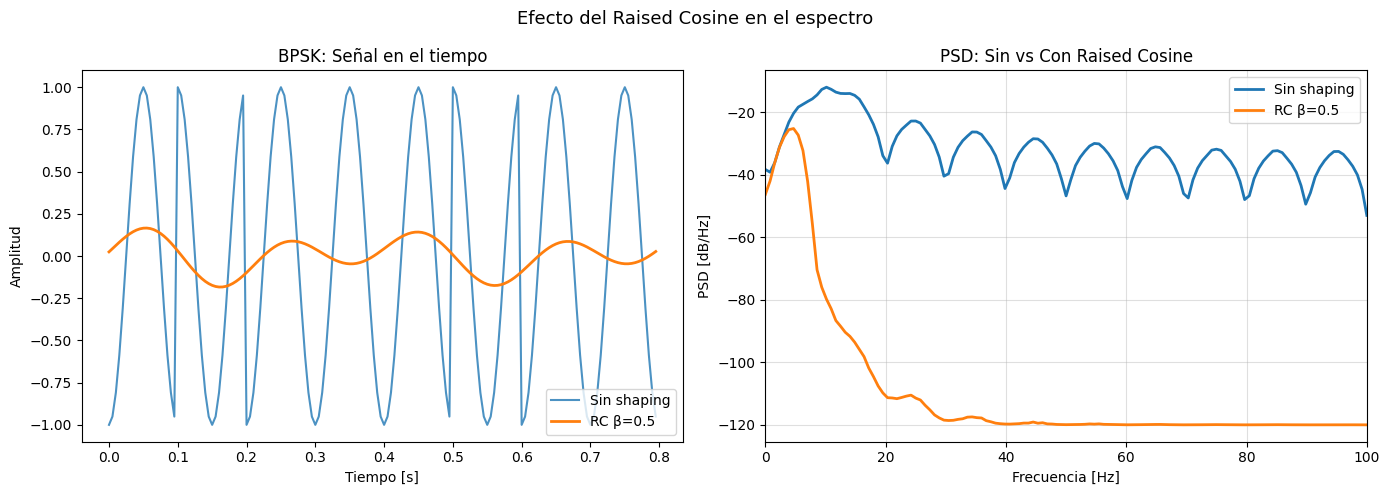

In [31]:
def raised_cosine_filter(beta: float, sps: int, n_taps: int = 6) -> torch.Tensor:
    """Genera impulso Raised Cosine centrado."""
    n_half = n_taps * sps
    t_arr  = np.arange(-n_half, n_half + 1) / sps  # en unidades de T
    h = np.zeros_like(t_arr)
    for i, ti in enumerate(t_arr):
        if ti == 0:
            h[i] = 1.0
        elif beta != 0 and abs(abs(ti) - 1 / (2 * beta)) < 1e-6:
            h[i] = (np.pi / 4) * np.sinc(1 / (2 * beta))
        else:
            num = np.sinc(ti) * np.cos(np.pi * beta * ti)
            den = 1 - (2 * beta * ti) ** 2
            h[i] = num / den
    h /= h.sum()  # Normalizar
    return torch.tensor(h, dtype=torch.float32)

def apply_shaping(signal: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
    """Aplica filtro RC por convolución."""
    sig_2d = signal.unsqueeze(0).unsqueeze(0)  # [1, 1, L]
    h_2d   = h.unsqueeze(0).unsqueeze(0)       # [1, 1, taps]
    pad    = h.shape[0] // 2
    out    = F.conv1d(sig_2d, h_2d, padding=pad)
    return out.squeeze()[:signal.shape[0]]

beta = 0.5  # Roll-off factor
h_rc = raised_cosine_filter(beta, sps)
bpsk_shaped = apply_shaping(bpsk_full, h_rc)

# PSD comparativa
f_ns, P_ns = compute_psd(bpsk_full,   fs)  # sin shaping
f_sh, P_sh = compute_psd(bpsk_shaped, fs)  # con shaping

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Señales en tiempo
axes[0].plot(np.arange(8*sps)/fs, bpsk_full[:8*sps].numpy(),   label='Sin shaping', alpha=0.8)
axes[0].plot(np.arange(8*sps)/fs, bpsk_shaped[:8*sps].numpy(), label=f'RC β={beta}', lw=2)
axes[0].set_title('BPSK: Señal en el tiempo'); axes[0].legend()
axes[0].set_xlabel('Tiempo [s]'); axes[0].set_ylabel('Amplitud')

# PSD
axes[1].plot(f_ns, P_ns, label='Sin shaping', lw=2)
axes[1].plot(f_sh, P_sh, label=f'RC β={beta}', lw=2)
axes[1].set_title('PSD: Sin vs Con Raised Cosine')
axes[1].set_xlabel('Frecuencia [Hz]'); axes[1].set_ylabel('PSD [dB/Hz]')
axes[1].set_xlim(0, fs/2); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Efecto del Raised Cosine en el espectro', fontsize=13)
plt.tight_layout(); plt.show()

### ❓ Pregunta — ¿Cómo afecta el Raised Cosine al espectro?

**Respuesta esperada:** El filtro Raised Cosine reduce significativamente los lóbulos laterales del espectro (fuera de la banda principal). Al suavizar las transiciones abruptas entre símbolos, la energía se concentra en una banda más estrecha alrededor de $f_c$. A mayor roll-off $\beta$, la transición es más suave (pero ocupa ligeramente más ancho de banda). Con $\beta=1$ se obtiene el filtro de Nyquist ideal (sinc), que minimiza el ancho de banda pero tiene ISI fuera del instante de muestreo.

---
## Parte 8 – QAM y APSK

### 16-QAM
Los 16 símbolos se distribuyen en una grilla cuadrada $4 \times 4$ en el plano IQ:
$$s_k = I_k + j Q_k, \quad I_k, Q_k \in \{-3, -1, +1, +3\}$$

### APSK (Amplitude Phase Shift Keying)
Los símbolos se distribuyen en anillos concéntricos (combinación de amplitud y fase). Usaremos 2 anillos.

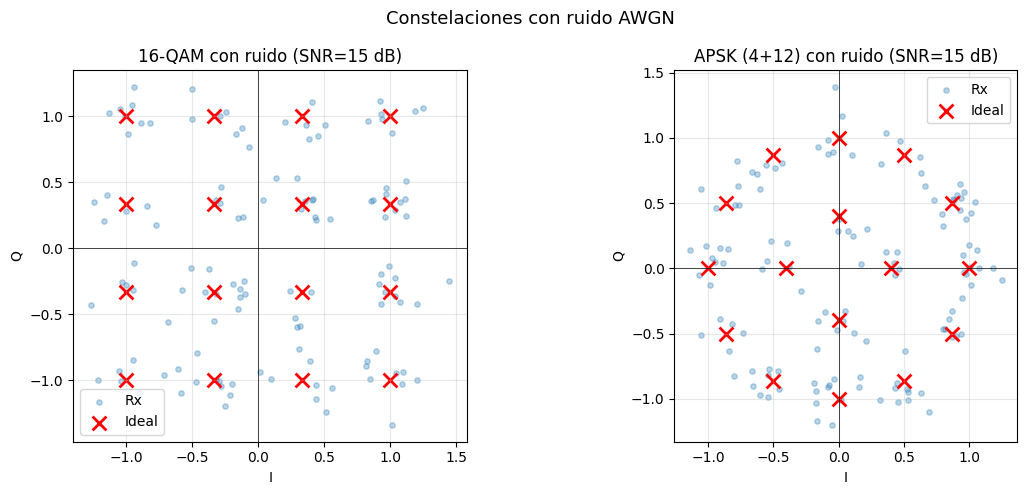

In [32]:
# ---- 16-QAM ----
qam_levels = torch.tensor([-3., -1., 1., 3.])
qam_const  = torch.stack([torch.stack([i, q]) for i in qam_levels for q in qam_levels])  # 16×2
qam_const /= qam_const.abs().max()  # Normalizar

def modulate_qam16(bits):
    """Mapeo Gray de 4 bits → símbolo QAM-16."""
    n_sym = len(bits) // 4
    bits_trim = bits[:n_sym * 4].reshape(n_sym, 4)
    indices   = (bits_trim[:, 0] * 8 + bits_trim[:, 1] * 4 +
                 bits_trim[:, 2] * 2 + bits_trim[:, 3]).long()
    return qam_const[indices]  # [n_sym, 2] → (I, Q)

# ---- APSK (2 anillos: 4 + 12 puntos) ----
r1, r2   = 0.4, 1.0
n1, n2   = 4, 12
angles1  = torch.linspace(0, 2 * np.pi, n1 + 1)[:-1]
angles2  = torch.linspace(0, 2 * np.pi, n2 + 1)[:-1]
ring1    = torch.stack([r1 * torch.cos(angles1), r1 * torch.sin(angles1)], dim=1)
ring2    = torch.stack([r2 * torch.cos(angles2), r2 * torch.sin(angles2)], dim=1)
apsk_const = torch.cat([ring1, ring2], dim=0)  # 16 puntos

def modulate_apsk(bits):
    n_sym = len(bits) // 4
    bits_trim = bits[:n_sym * 4].reshape(n_sym, 4)
    indices   = (bits_trim[:, 0] * 8 + bits_trim[:, 1] * 4 +
                 bits_trim[:, 2] * 2 + bits_trim[:, 3]).long()
    return apsk_const[indices]

def demod_nearest(rx_symbols, constellation):
    """Detector de mínima distancia euclidiana."""
    dists = torch.cdist(rx_symbols.unsqueeze(0), constellation.unsqueeze(0))[0]
    return dists.argmin(dim=1)

def add_iq_noise(symbols, snr_db):
    power   = symbols.pow(2).mean()
    snr_lin = 10 ** (snr_db / 10)
    sigma   = torch.sqrt(power / snr_lin)
    return symbols + torch.randn_like(symbols) * sigma

snr_qam = 15  # dB

# Símbolos transmitidos
qam_sym_tx  = modulate_qam16(bits)
apsk_sym_tx = modulate_apsk(bits)

# Con ruido
qam_sym_rx  = add_iq_noise(qam_sym_tx,  snr_qam)
apsk_sym_rx = add_iq_noise(apsk_sym_tx, snr_qam)

# ---- Constelaciones ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(qam_sym_rx[:, 0].numpy(),  qam_sym_rx[:, 1].numpy(),  alpha=0.3, s=15, label='Rx')
axes[0].scatter(qam_const[:, 0].numpy(),   qam_const[:, 1].numpy(),   s=100, c='red', marker='x', lw=2, label='Ideal')
axes[0].set_title(f'16-QAM con ruido (SNR={snr_qam} dB)')
axes[0].set_xlabel('I'); axes[0].set_ylabel('Q'); axes[0].legend()
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3)

axes[1].scatter(apsk_sym_rx[:, 0].numpy(), apsk_sym_rx[:, 1].numpy(), alpha=0.3, s=15, label='Rx')
axes[1].scatter(apsk_const[:, 0].numpy(),  apsk_const[:, 1].numpy(),  s=100, c='red', marker='x', lw=2, label='Ideal')
axes[1].set_title(f'APSK (4+12) con ruido (SNR={snr_qam} dB)')
axes[1].set_xlabel('I'); axes[1].set_ylabel('Q'); axes[1].legend()
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
axes[1].set_aspect('equal'); axes[1].grid(alpha=0.3)

plt.suptitle('Constelaciones con ruido AWGN', fontsize=13)
plt.tight_layout(); plt.show()

---
## Parte 9 – Comparación Final: BER vs SNR

Calculamos la curva **BER vs SNR** para todas las modulaciones y la comparamos con los resultados teóricos:

$$\text{BER}_{BPSK} = Q\left(\sqrt{2 E_b/N_0}\right), \quad Q(x) = \frac{1}{2}\text{erfc}\left(\frac{x}{\sqrt{2}}\right)$$

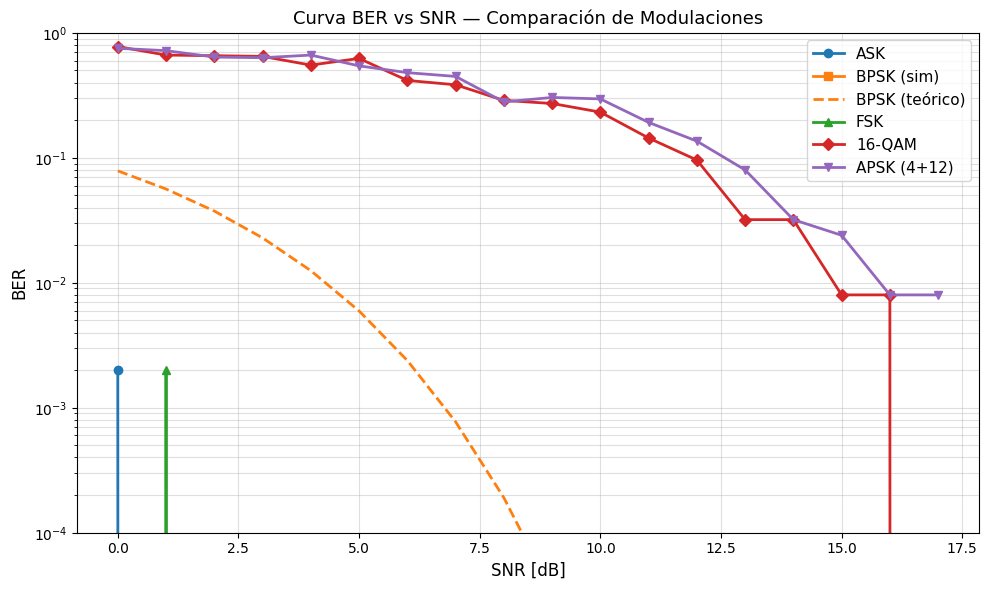

In [24]:
from scipy.special import erfc

snr_range = np.arange(0, 18, 1)  # dB

ber_ask_vec, ber_bpsk_vec, ber_fsk_vec = [], [], []
ber_qam_vec, ber_apsk_vec = [], []

for snr in snr_range:
    # ASK
    rx, _ = add_awgn(ask_full, snr)
    ber_ask_vec.append(ber(bits, correlate_demod(rx, t, fc, sps, mode='ask')))
    # BPSK
    rx, _ = add_awgn(bpsk_full, snr)
    ber_bpsk_vec.append(ber(bits, correlate_demod(rx, t, fc, sps, mode='bpsk')))
    # FSK
    rx, _ = add_awgn(fsk_full, snr)
    ber_fsk_vec.append(ber(bits, demod_fsk(rx, t, f0, f1, sps)))
    # QAM-16
    rx_sym = add_iq_noise(qam_sym_tx, snr)
    idx_rx = demod_nearest(rx_sym, qam_const)
    idx_tx = demod_nearest(qam_sym_tx, qam_const)
    ber_qam_vec.append((idx_rx != idx_tx).float().mean().item())
    # APSK
    rx_sym = add_iq_noise(apsk_sym_tx, snr)
    idx_rx = demod_nearest(rx_sym, apsk_const)
    idx_tx = demod_nearest(apsk_sym_tx, apsk_const)
    ber_apsk_vec.append((idx_rx != idx_tx).float().mean().item())

# Curva teórica BPSK: BER = 0.5·erfc(sqrt(SNR_lin))
snr_lin_th  = 10 ** (snr_range / 10)
ber_bpsk_th = 0.5 * erfc(np.sqrt(snr_lin_th))

# ---- Curva BER vs SNR ----
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(snr_range, ber_ask_vec,  'o-',  label='ASK',           lw=2)
ax.semilogy(snr_range, ber_bpsk_vec, 's-',  label='BPSK (sim)',    lw=2)
ax.semilogy(snr_range, ber_bpsk_th,  '--',  label='BPSK (teórico)', lw=2, color='C1')
ax.semilogy(snr_range, ber_fsk_vec,  '^-',  label='FSK',           lw=2)
ax.semilogy(snr_range, ber_qam_vec,  'D-',  label='16-QAM',        lw=2)
ax.semilogy(snr_range, ber_apsk_vec, 'v-',  label='APSK (4+12)',   lw=2)

ax.set_xlabel('SNR [dB]', fontsize=12)
ax.set_ylabel('BER', fontsize=12)
ax.set_title('Curva BER vs SNR — Comparación de Modulaciones', fontsize=13)
ax.legend(fontsize=11)
ax.grid(which='both', alpha=0.4)
ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.show()

---
## Conclusiones

| Modulación | Robustez al ruido | Eficiencia espectral | Complejidad |
|------------|:-----------------:|:--------------------:|:-----------:|
| ASK Unipolar | Baja | Media | Baja |
| BPSK | Alta | Baja (1 bit/símbolo) | Baja |
| FSK | Media | Baja (mayor BW) | Media |
| 16-QAM | Media | Alta (4 bits/símbolo) | Alta |
| APSK | Media-Alta | Alta | Alta |

### Conclusiones del Taller

1. **ASK ≡ BPSK bipolar:** La ASK unipolar puede transformarse a bipolar mediante $s_{bip} = 2s_{ASK} - c(t)$, obteniendo exactamente BPSK.

2. **BPSK más robusto que ASK:** Mayor distancia euclidiana entre puntos de la constelación → menor BER para el mismo SNR.

3. **FSK ocupa más ancho de banda:** Al utilizar dos frecuencias, genera dos lóbulos espectrales independientes.

4. **El ruido dispersa la constelación:** A mayor SNR, los puntos recibidos se concentran alrededor de los símbolos ideales.

5. **Raised Cosine reduce el ancho de banda:** Suaviza las transiciones → menos energía en lóbulos laterales.

6. **La modulación es geometría en el plano IQ:** El desempeño queda determinado por la distancia mínima entre puntos de la constelación y la energía media de los símbolos.

---
## Bonus – Comparación Simulación vs Teoría BPSK

Se compara directamente la curva BER simulada de BPSK con el resultado analítico:
$$\text{BER}_{BPSK} = \frac{1}{2}\text{erfc}\!\left(\sqrt{E_b/N_0}\right)$$

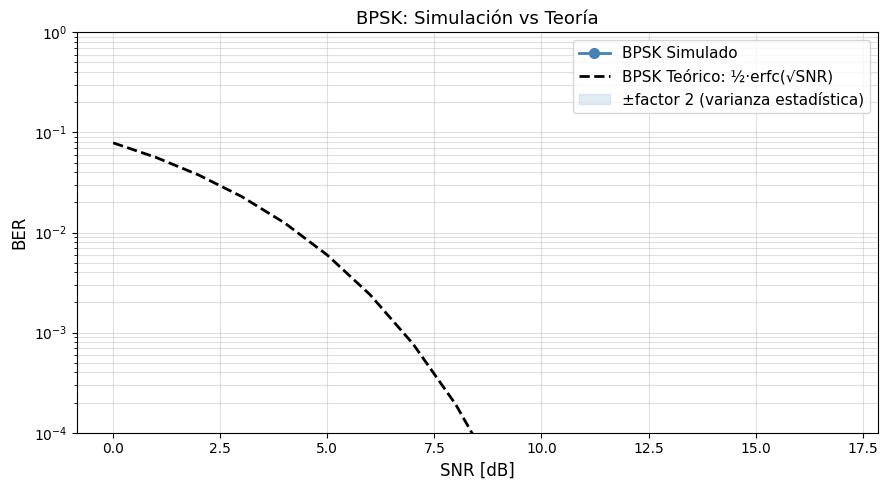


📊 Tabla comparativa BER BPSK:
  SNR (dB)     Simulado      Teórico
------------------------------------
         0       0.0000       0.0786
         1       0.0000       0.0563
         2       0.0000       0.0375
         3       0.0000       0.0229
         4       0.0000       0.0125
         5       0.0000       0.0060
         6       0.0000       0.0024
         7       0.0000       0.0008
         8       0.0000       0.0002
         9       0.0000       0.0000
        10       0.0000       0.0000
        11       0.0000       0.0000
        12       0.0000       0.0000
        13       0.0000       0.0000
        14       0.0000       0.0000
        15       0.0000       0.0000
        16       0.0000       0.0000
        17       0.0000       0.0000


In [25]:
# Comparación detallada BPSK simulado vs teórico
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(snr_range, ber_bpsk_vec, 'o-',  color='steelblue', label='BPSK Simulado',   lw=2, ms=7)
ax.semilogy(snr_range, ber_bpsk_th,  'k--', label='BPSK Teórico: ½·erfc(√SNR)', lw=2)
ax.fill_between(snr_range,
                np.array(ber_bpsk_vec) * 0.5,
                np.array(ber_bpsk_vec) * 2.0,
                alpha=0.15, color='steelblue', label='±factor 2 (varianza estadística)')
ax.set_xlabel('SNR [dB]', fontsize=12)
ax.set_ylabel('BER', fontsize=12)
ax.set_title('BPSK: Simulación vs Teoría', fontsize=13)
ax.legend(fontsize=11)
ax.grid(which='both', alpha=0.4)
ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.show()

print('\n📊 Tabla comparativa BER BPSK:')
print(f'{"SNR (dB)":>10} {"Simulado":>12} {"Teórico":>12}')
print('-' * 36)
for snr, b_sim, b_th in zip(snr_range, ber_bpsk_vec, ber_bpsk_th):
    print(f'{snr:>10.0f} {b_sim:>12.4f} {b_th:>12.4f}')